# PayJoy Prediction Challenge 2026

The purpose of this document is to outline the data specifics and the creation process for the `benchmark_submission.csv` file in the competition. Additionally, it includes code snippets for conducting exploratory data analysis and building a benchmark model.

## Competition Overview

PayJoy provides phone financing to customers across Latin America, Africa, India, and Southeast Asia. When a customer purchases a smartphone using PayJoy financing, they are expected to make regular payments. A key risk indicator is **First Payment Default (FPD_15)** — whether a customer fails to make their first payment within 15 days of the due date.

**Your task:** Predict which orders in December 2025 will result in FPD_15 (first payment default).

### Background

Please refer to the companion document [PayJoy Prediction Challenge Student Instructions](https://docs.google.com/document/d/1nlNFtuZJ-gGkNANmF4AzGt7AAc8BZ8we7kRYoiiCLw8/edit?usp=drive_link) for:
- PayJoy company background
- Detailed data dictionary
- Business context for the prediction task

### Setup Instructions

If you are running this notebook on your own computer (through Cursor, Jupyter Notebook, VS Code, or any other setup), download the data files from the Google Drive link and place them in the **same directory** as this notebook file before running the cells.

If you are using Colab, follow the Colab instructions and download/open the separate notebook prepared specifically for Colab users.

### Evaluation Metric

The primary metric for evaluating predictions is **AUC-ROC** (Area Under the Receiver Operating Characteristic Curve). AUC measures the model's ability to distinguish between positive (FPD_15=1) and negative (FPD_15=0) cases.

- AUC = 1.0: Perfect classifier
- AUC = 0.5: Random guessing
- Higher AUC is better

The leaderboard ranking will be determined based on the AUC calculated from 25% of the test set (public test set). The final evaluation will use the remaining 75% of the test set (private test set), chosen randomly to ensure fairness.

### Dataset Composition

Think of the data as a snapshot taken at the beginning of December 2025. At this point, you have:
- All orders placed from January through December 2025
- Payment history through the end of November 2025 for all pre-December orders
- For December orders: only the information known at the time of the order (no payment history yet)

**File Descriptions:**

- `Orders.csv` — Order details for phone financing transactions (~1.2M rows). For December orders, `FPD_15` and payment-related columns are not available (these are what you're predicting).
- `Payment_History.csv` — Monthly payment snapshots for pre-December orders (~5.7M rows). Each row represents the cumulative state of a loan at a given month.
- `Test_OrderIDs.csv` — Order IDs for December 2025 orders for which you need to predict FPD_15.
- `submission.csv` — Sample submission file (generated by this notebook).
- `Prediction Challenge, Notes and Benchmark.ipynb` — This notebook.

**Data Confidentiality Agreement:** Do not share the datasets with anybody except the OIT367 students and course staff.

## Benchmark Code

This section demonstrates building a simple logistic regression model as a benchmark. You should aim to substantially improve upon this baseline.

In [1]:
import numpy as np
np.random.seed(42)
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(style='whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

### Load the Data

In [2]:
# Load datasets
orders = pd.read_csv('Orders.csv', low_memory=False)
payments = pd.read_csv('Payment_History.csv')
test_ids = pd.read_csv('Test_OrderIDs.csv')

print(f"Orders shape: {orders.shape}")
print(f"Payments shape: {payments.shape}")
print(f"Test IDs: {len(test_ids)}")

Orders shape: (1196476, 33)
Payments shape: (5661938, 8)
Test IDs: 98932


In [3]:
# Preview the orders data
orders.head()

,FINANCEORDERID,TRANSACTIONTIME,FINANCE_AMOUNT,LOAN_START_DATE,PURCHASE_AMOUNT,FIRST_PAYMENT_DUE_TIMESTAMP,FIRST_PAYMENT_TIMESTAMP,COUNTRY,USER_STATE,MERCHANT_STATE,...,MODEL,MANUFACTURER,FPD_15,PAID_AMOUNT,BALANCE,NUMBER_OF_PAYMENTS,FACE_RECOGNITION_SCORE,IDVALIDATION_OVERALL_SCORE,LIVENESS_SCORE,OVERALL_SCORE
0,13365703,2025-09-05 19:29:29+00,4060.00,2025-09-05 20:29:29+00:00,4499.0,2025-09-12 20:00:00+00,2025-09-11 15:38:30+00,MX,PUE,PUE,...,A5 4G,OPPO,0.0,3843.00,5673.00,21.0,86.4,100.0,100.0,95.5
1,11091798,2025-03-11 17:07:10+00,2011.00,2025-03-11 18:07:10+00:00,2299.0,2025-03-18 20:00:00+00,2025-03-18 20:59:30+00,MX,DGO,DGO,...,Galaxy A06 (SM-A065M),SAMSUNG,0.0,2145.00,2145.00,13.0,89.6,100.0,100.0,96.5
2,11552944,2025-04-20 10:40:29+00,562.50,2025-04-20 12:40:29+00:00,750.0,2025-04-27 20:00:00+00,2025-04-27 18:18:53+00,PE,PE-SAM,PE-SAM,...,Redmi 14C,XIAOMI,0.0,1329.17,27.67,35.0,90.4,100.0,100.0,96.8
3,13192752,2025-08-24 14:14:16+00,2475.00,2025-08-24 15:14:16+00:00,3300.0,2025-08-31 20:00:00+00,2025-09-05 17:44:07+00,MX,MEX,SLP,...,Smart 9,INFINIX,0.0,3978.00,0.00,13.0,87.3,100.0,100.0,95.8
4,13452868,2025-09-12 15:02:32+00,701.22,2025-09-12 19:02:32+00:00,899.0,2025-09-26 23:59:59+00,2025-10-01 21:28:38+00,BR,NaN,BR-RJ,...,Moto G05,MOTOROLA,0.0,1192.56,6.40,7.0,87.3,100.0,99.9,95.7


In [4]:
# Check column data types and missing values
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 1196476 entries, 0 to 1196475
Data columns (total 33 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   FINANCEORDERID               1196476 non-null  int64  
 1   TRANSACTIONTIME              1196476 non-null  str    
 2   FINANCE_AMOUNT               1196476 non-null  float64
 3   LOAN_START_DATE              1196476 non-null  str    
 4   PURCHASE_AMOUNT              1196476 non-null  float64
 5   FIRST_PAYMENT_DUE_TIMESTAMP  1196476 non-null  str    
 6   FIRST_PAYMENT_TIMESTAMP      1019499 non-null  str    
 7   COUNTRY                      1196476 non-null  str    
 8   USER_STATE                   1151185 non-null  str    
 9   MERCHANT_STATE               1196476 non-null  str    
 10  STATE                        1196476 non-null  str    
 11  STATE_NAME                   974794 non-null   str    
 12  CITY                         1196397 non-null  str   

### Prepare Training and Test Sets

- **Training data:** Orders with known FPD_15 labels (January - November 2025)
- **Test data:** Orders in Test_OrderIDs.csv (December 2025, labels hidden)

In [6]:
# Identify training data (orders with known FPD_15)
train_data = orders[orders['FPD_15'].notna()].copy()
test_data = orders[orders['FINANCEORDERID'].isin(test_ids['FINANCEORDERID'])].copy()

print(f"Training orders: {len(train_data):,}")
print(f"Test orders: {len(test_data):,}")
print(f"\nTraining FPD_15 distribution:")
print(train_data['FPD_15'].value_counts(normalize=True))

Training orders: 1,097,544
Test orders: 98,932

Training FPD_15 distribution:
FPD_15
0.0    0.903786
1.0    0.096214
Name: proportion, dtype: float64


### Feature Engineering (Basic Example)

This is a minimal example using only a few numeric features. You should explore the data and create better features!

In [7]:
# Select some basic numeric features for the benchmark
# You should explore and engineer better features!
numeric_features = [
    'FINANCE_AMOUNT',
    'PURCHASE_AMOUNT',
    'TOTAL_DUE',
    'DOWN_PAYMENT_AMOUNT',
    'FACE_RECOGNITION_SCORE',
    'IDVALIDATION_OVERALL_SCORE',
    'LIVENESS_SCORE',
    'OVERALL_SCORE'
]

# Prepare training features and target
X_train = train_data[numeric_features].fillna(0)
y_train = train_data['FPD_15']

# Prepare test features
X_test = test_data[numeric_features].fillna(0)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1097544, 8)
X_test shape: (98932, 8)


### Model Training and Validation

We split the training data to validate our model before making final predictions.

In [8]:
# Split training data for validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val)

# Train logistic regression
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train_split)

# Predict probabilities
train_pred_proba = model.predict_proba(X_train_scaled)[:, 1]
val_pred_proba = model.predict_proba(X_val_scaled)[:, 1]

# Calculate AUC
train_auc = roc_auc_score(y_train_split, train_pred_proba)
val_auc = roc_auc_score(y_val, val_pred_proba)

print(f"Training AUC: {train_auc:.4f}")
print(f"Validation AUC: {val_auc:.4f}")

Training AUC: 0.5124
Validation AUC: 0.5128


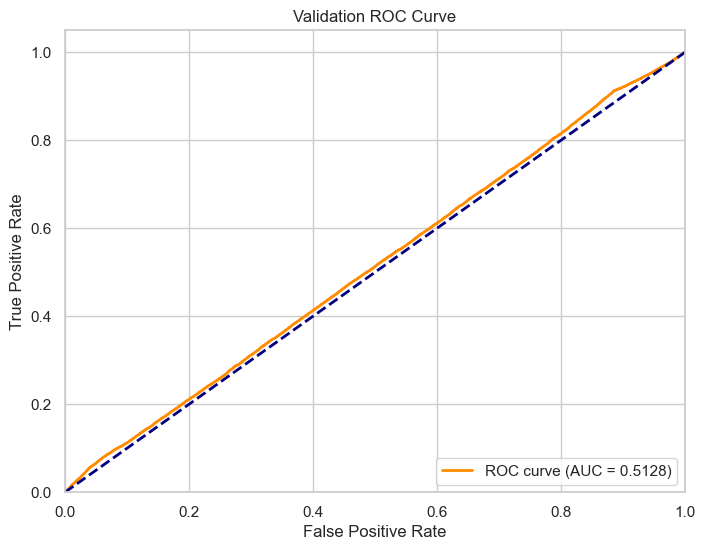

In [9]:
# Plot ROC curve
fpr, tpr, _ = roc_curve(y_val, val_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {val_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Validation ROC Curve')
plt.legend(loc='lower right')
plt.show()

The plot above shows the model's ROC curve on the validation set. The AUC is close to 0.5, indicating this benchmark is barely better than random guessing.

**Note:** This notebook represents only a basic benchmark model. For the actual assignment, you should perform substantial model building and testing here — trying different algorithms, tuning hyperparameters, and rigorously validating performance. Only once you are satisfied with your model selection process should you move on to the final section where we train on the full dataset and generate predictions for the Kaggle submission.

### Train Final Model and Generate Predictions

Now train on the full training set and predict for the test set.

In [10]:
# Train on full training data
scaler_full = StandardScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train)
X_test_scaled = scaler_full.transform(X_test)

model_full = LogisticRegression(random_state=42, max_iter=1000)
model_full.fit(X_train_full_scaled, y_train)

# Predict probabilities for test set
test_pred_proba = model_full.predict_proba(X_test_scaled)[:, 1]

print(f"Generated predictions for {len(test_pred_proba):,} test orders")

Generated predictions for 98,932 test orders


### Create Submission File

In [11]:
# Create submission dataframe
submission = pd.DataFrame({
    'FINANCEORDERID': test_data['FINANCEORDERID'].astype(str),
    'FPD_15_pred': test_pred_proba
})

# Sort by FINANCEORDERID
submission = submission.sort_values('FINANCEORDERID').reset_index(drop=True)

# Save to CSV
submission.to_csv('benchmark_submission.csv', index=False)

print("Submission file saved!")
submission.head()

Submission file saved!


,FINANCEORDERID,FPD_15_pred
0,14567910,0.096856
1,14568276,0.096602
2,14568515,0.130451
3,14568688,0.114505
4,14568707,0.112761


### Submission Validation Checklist

Before submitting, let's verify the submission file meets all requirements.

In [12]:
print("Running submission validation checks...\n")

# Check 1: Verify no duplicate FINANCEORDERID
if submission['FINANCEORDERID'].duplicated().any():
    print("WARNING: Submission contains duplicate FINANCEORDERID values!")
else:
    print("[OK] No duplicate FINANCEORDERIDs found")

# Check 2: Verify all test set IDs are present
test_ids_set = set(test_ids['FINANCEORDERID'].astype(str))
submission_ids_set = set(submission['FINANCEORDERID'])
missing_ids = test_ids_set - submission_ids_set
if missing_ids:
    print(f"WARNING: Missing {len(missing_ids)} FINANCEORDERIDs in submission!")
else:
    print("[OK] All test set FINANCEORDERIDs are present")

# Check 3: Verify predictions are valid probabilities (0 to 1)
if (submission['FPD_15_pred'] < 0).any() or (submission['FPD_15_pred'] > 1).any():
    print("WARNING: Predictions should be probabilities between 0 and 1!")
else:
    print("[OK] All predictions are valid probabilities (0-1)")

# Check 4: Verify no missing values
if submission.isnull().any().any():
    print("WARNING: Submission contains missing values!")
else:
    print("[OK] No missing values found")

print("\n" + "="*50)
print("If you see any WARNING messages above, please fix before submitting!")

Running submission validation checks...

[OK] No duplicate FINANCEORDERIDs found
[OK] All test set FINANCEORDERIDs are present
[OK] All predictions are valid probabilities (0-1)
[OK] No missing values found

If you see any WARNING messages above, please fix before submitting!


## Next Steps

This benchmark model is intentionally simple. To improve your score, consider:

1. **Feature Engineering:**
   - Understand patterns of fraud and built better features


2. **Model Selection:**
   - Try different algorithms (Random Forest, XGBoost, LightGBM, Neural Networks)
   - Ensemble multiple models

3. **Hyperparameter Tuning:**
   - Use cross-validation
   - Grid search or Bayesian optimization

Good luck!